In [1]:
# Stage 1: Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Stage 2: Load Dataset
# Loading the spam email dataset.

In [4]:
df = pd.read_csv("spam.csv")

In [5]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.shape

(5572, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
# Stage 3: Data Understanding
# Checking the distribution of spam and ham messages.

In [9]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

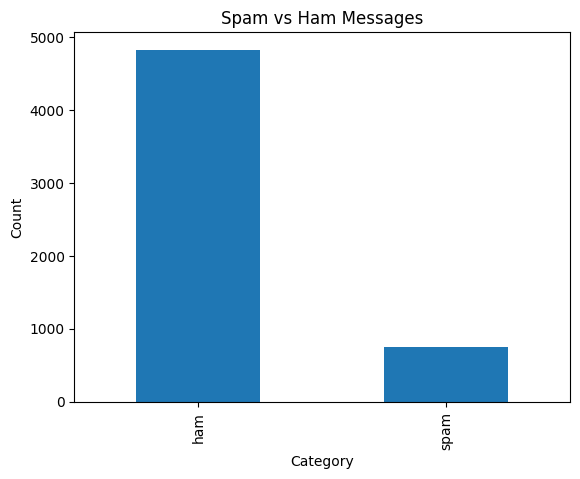

In [10]:
df['Category'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [11]:
# Stage 4: Data Cleaning
# Checking for missing values and duplicate records.

In [12]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(415)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
# Stage 5: Convert Target Variable
# Converting labels into numerical values.

# Why?
# Machine learning models work with numbers.

In [16]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

In [17]:
# Stage 6: Text Vectorization
# Converting text messages into numerical features using TF-IDF.

In [18]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df['Message']
)

y = df['Category']

In [19]:
# Stage 7: Train-Test Split
# Splitting data into training and testing sets.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Stage 8: Logistic Regression

In [22]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(
    y_test,
    pred_lr
)

print("Accuracy:", accuracy_lr)

Accuracy: 0.9563953488372093


In [23]:
# Stage 9: KNN Classifier

In [24]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(
    y_test,
    pred_knn
)

print("Accuracy:", accuracy_knn)

Accuracy: 0.9031007751937985


In [25]:
# Stage 10: Random Forest Classifier

In [26]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(
    y_test,
    pred_rf
)

print("Accuracy:", accuracy_rf)

Accuracy: 0.9815891472868217


In [27]:
# Stage 11: AdaBoost Classifier

In [28]:
ab = AdaBoostClassifier(
    random_state=42
)

ab.fit(X_train, y_train)

pred_ab = ab.predict(X_test)

accuracy_ab = accuracy_score(
    y_test,
    pred_ab
)

print("Accuracy:", accuracy_ab)

Accuracy: 0.9544573643410853


In [29]:
# Stage 12: Model Comparison

In [30]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'AdaBoost'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_knn,
        accuracy_rf,
        accuracy_ab
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.956395
1,KNN,0.903101
2,Random Forest,0.981589
3,AdaBoost,0.954457


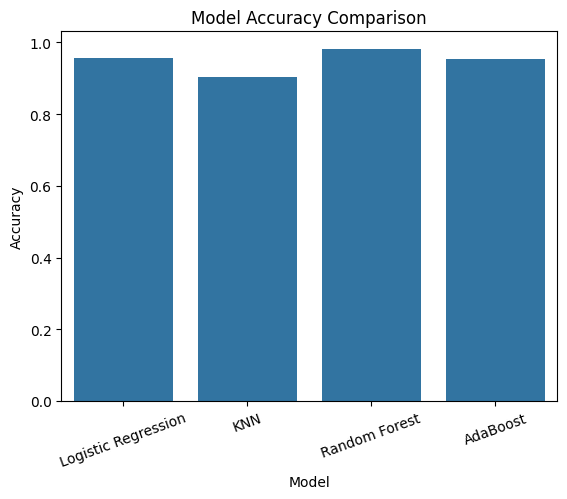

In [31]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

In [32]:
# Stage 13: Best Model Evaluation

In [33]:
print(
    confusion_matrix(
        y_test,
        pred_rf
    )
)

[[895   1]
 [ 18 118]]


In [34]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       896
           1       0.99      0.87      0.93       136

    accuracy                           0.98      1032
   macro avg       0.99      0.93      0.96      1032
weighted avg       0.98      0.98      0.98      1032



In [35]:
# Final Findings
# 1. The dataset contained 5,157 SMS messages, including 4,516 ham (non-spam) messages and 641 spam messages.
# 2. Logistic Regression achieved an accuracy of 95.64%, showing strong performance in distinguishing spam and non-spam messages.
# 3. KNN achieved an accuracy of 90.31%, which was lower than the other models.
# 4. AdaBoost Classifier achieved an accuracy of 95.45%, performing similarly to Logistic Regression.
# 5. Random Forest Classifier achieved the highest accuracy of 98.16%, making it the best-performing model in this analysis.
# 6. The confusion matrix showed that the Random Forest model correctly classified most messages, with only 19 misclassifications out of 1,032 test messages.
# 7. The classification report showed high precision, recall, and F1-scores, indicating reliable spam detection performance.